# AED - suco uva - Tabelas e Gráficos (Python)

## Objetivos da Aprendizagem

> Após ler este relatório de pesquisa, você deve ser capaz de:
>
> ▶ 1 Calcular e interpretar distribuições marginais em tabelas de dupla entrada.
>
> ▶ 2 Calcular e interpretar distribuições condicionais em tabelas de dupla entrada.
>
> ▶ 3 Reconhecer e explicar o paradoxo de Simpson. [@Moore2023 , p. 130].
>
> ▶ 4 Resumir dados em tabelas de dupla entrada e interpretá-las.
>
> ▶ 5 Visualizar gráficos adequados para esse tipo de dado e interpretá-los.
>
> ▶ 6 Capturar modelos adequados e interpretá-los.

Os dados dessa pesquisa empírica em Direito e Políticas Públicas foram extraídos de [@Aline-2020-sucouva].

## Suco de uva

Os dados a seguir foram reproduzidos a partir das seguintes imagens que se encontram no seguinte artigo publicado:
TOMÁS, Aline Vieira. Resultados alcançados pelo projeto Adoce: acordos após ingestão de glicose observados em conciliações judiciais (processuais) e extrajudiciais (pré-processuais). _Revista Eletrônica CNJ_, v. 4, n. 2, p. 212–232, 2020.



Tabela 5 – Desempenho dos conciliadores – Tabelas com qui-quadrado (Tomás, 2020, p. 222)  
![](fig\dados-suco-uva-conciliadores-GCxGT-tab5-obs-esp-quiquad.png)  
Qui-quadrado = 33.0268 / P-valor: .00.  
Hipótese nula: não há diferença estatística entre os dois grupos (conciliador e grupos da pesquisa).  
Hipótese alternativa: há diferença estatística entre os dois grupos.  
Ou seja, há uma diferença de desempenho dos conciliadores entre os grupos.  
Fonte: Dados da pesquisa.  
  
Os graus de liberdade da Tabela 5, acima, são:
gl = (l-1).(c-1) = (2-1).(4-1) = 1 . 3 = 3 (três graus de liberdade)  
De modo que o correspondente valor crítico da respectiva distribuição teórica do qui-quadrado é: 7,82

Tabela 6 – Quantidade e proporção de indivíduos que ingeriram e não ingeriram suco no grupo experimental (Tomás, 2020, p. 223)  
![](fig\dados-suco-uva-tab6-quant-prop-ind-ingeriu-nao_inger-suco_uva.png)  
  
O código a seguir replica essas tabelas de dados primários levantados pela pesquisa delienada com um ECCA - Experimento Controlado Comparativo Aleatorizado.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

MONTH_LEVELS = [
    "Abril", "Maio", "Junho", "Julho", "Agosto",
    "Setembro", "Outubro", "Novembro", "Dezembro"
]


def map_month(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    low = s.lower()
    lookup = {m.lower(): m for m in MONTH_LEVELS}
    if low in lookup:
        return lookup[low]
    return s


def stars_from_p(p):
    if p is None or pd.isna(p):
        return ""
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "."
    return ""


def stars_from_p_facet(p):
    if p is None or pd.isna(p):
        return ""
    if p < 0.001:
        return "<0.001"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "."
    return ""


def chi_or_fisher_2x2(matrix_2x2):
    try:
        chi2, p_chi, _, expected = chi2_contingency(matrix_2x2, correction=False)
        if np.any(expected < 5):
            _, p_f = fisher_exact(matrix_2x2)
            return {"test": "Fisher", "p": float(p_f), "stat": np.nan, "expected": expected}
        return {"test": "Chi-square", "p": float(p_chi), "stat": float(chi2), "expected": expected}
    except Exception:
        _, p_f = fisher_exact(matrix_2x2)
        return {"test": "Fisher", "p": float(p_f), "stat": np.nan, "expected": None}


def wilson_ci(successes, total, z=1.959963984540054):
    if total <= 0:
        return (np.nan, np.nan)
    p = successes / total
    denom = 1 + (z ** 2) / total
    center = (p + (z ** 2) / (2 * total)) / denom
    half = z * np.sqrt((p * (1 - p) + (z ** 2) / (4 * total)) / total) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def normalize_col(name):
    s = str(name).strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


def pct_str(x, digits=1):
    return f"{100*x:.{digits}f}%"

### Replicar tabela mês a mês

Grupo de Controle (GC) -x- Grupo de Tratamento (GT)

Tabela 3 – Testes qui-quadrado que comparam as diferenças entre as proporções de acordos, mês a mês (Tomás, 2020, p. 220)  
![](fig\dados-suco-uva-tab3-testes-quiquad.png)  
"Nota da Tabela 3.  
*** teste significativo a 99% de confiança;  
** teste significativo a 95% de confiança;  
\* teste significativo a 90% de confiança (menos robusto).  
N = 659 audiências de conciliação.  
Grupo Experimental (N = 354audiências);  
Grupo de Controle (N = 305 audiências).  
Teste qui-quadrado para amostras independentes (grupos experimental e de controle, amostra total): qui-quadrado = 66.87, p= 0.00, significativo a 99% de nível de confiança.  
1 Testes qui-quadrado mês a mês.  
2 Apenas 28 audiências de conciliação aconteceram no mês de outubro. Motivo: férias da magistrada.  
3 A Semana Nacional de Conciliação ocorreu entre os dias 5 e 9 de novembro de 2018.  
4 Apenas 28 audiências de conciliação aconteceram no mês de dezembro. Motivo: Recesso forense a partir de 20 de dezembro.  
Fonte: Dados da pesquisa." (Tomás, 2020, p. 221)  
  
Note-se que o título 'Valor do qui-quadrado' deveria corresponder à última coluna da tabela 3 publicada no artigo utilizado como fonte para os dados primários coletados.  
Isso porque a penúltima coluna contém os dados observados para o resultado 'Acordo?' do tipo 'Sim' e não os resultados, mês a mês, do teste do Qui-quadrado de significância (com 99% de nível de confiança) contra a Hipótese Nula de não associação entre ingestão do suco de uva nos Grupos de Controle e Experimental e o Resultado da obtenação ou não de Acordo na audiência de conciliação realizada pelo Cejusc.  
Foi necessária __uma correção__ no dado primário lançado para a célula Mês de 'Abril', do Grupo 'Experimental', 'Acordo?' do tipo 'Sim': ao invés de '__74__', foi corrigido para '__54__'.  
Conferir o motivo explicado logo após a geração da tabela 3, a seguir.  

In [9]:
dados = pd.DataFrame(
    {
        "Mes": [
            "Abril", "Abril", "Maio", "Maio", "Junho", "Junho", "Julho", "Julho",
            "Agosto", "Agosto", "Setembro", "Setembro", "Outubro", "Outubro",
            "Novembro", "Novembro", "Dezembro", "Dezembro"
        ],
        "Grupo": [
            "Controle", "Experimental", "Controle", "Experimental", "Controle", "Experimental",
            "Controle", "Experimental", "Controle", "Experimental", "Controle", "Experimental",
            "Controle", "Experimental", "Controle", "Experimental", "Controle", "Experimental"
        ],
        "Nao": [35, 20, 17, 7, 18, 17, 20, 4, 19, 8, 24, 13, 8, 3, 16, 10, 10, 2],
        "Sim": [31, 54, 16, 38, 13, 19, 14, 33, 20, 24, 26, 30, 6, 11, 8, 49, 4, 12],
    }
)

res_rows = []
for mes, sub in dados.groupby("Mes", sort=False):
    c = sub.loc[sub["Grupo"] == "Controle", ["Nao", "Sim"]].iloc[0].to_numpy(dtype=float)
    e = sub.loc[sub["Grupo"] == "Experimental", ["Nao", "Sim"]].iloc[0].to_numpy(dtype=float)
    m = np.array([c, e])
    try:
        chi2, p, _, _ = chi2_contingency(m, correction=False)
        chi_fmt = f"{chi2:.2f}{stars_from_p(p)}"
        p_fmt = f"{p:.4f}"
    except Exception:
        chi_fmt, p_fmt = "", ""
    res_rows.append({"Mes": mes, "chi": chi_fmt, "pval": p_fmt})

res_list = pd.DataFrame(res_rows)

tabela_final = (
    dados.merge(res_list, on="Mes", how="left")
    .assign(
        Valor_do_qui_quadrado=lambda d: np.where(d["Grupo"].eq("Controle"), d["chi"], ""),
        Valor_p=lambda d: np.where(d["Grupo"].eq("Controle"), d["pval"], ""),
    )
    [["Mes", "Grupo", "Nao", "Sim", "Valor_do_qui_quadrado", "Valor_p"]]
)

print("Replicação, com uma correção e acréscimo de uma coluna com o Valor_p,\nda Tabela 3 com qui-quadrado por mês (aparecendo na linha Controle):")
display(tabela_final)

Replicação, com uma correção e acréscimo de uma coluna com o Valor_p,
da Tabela 3 com qui-quadrado por mês (aparecendo na linha Controle):


,Mes,Grupo,Nao,Sim,Valor_do_qui_quadrado,Valor_p
0,Abril,Controle,35,31,9.89**,0.0017
1,Abril,Experimental,20,54,,
2,Maio,Controle,17,16,11.56**,0.0007
3,Maio,Experimental,7,38,,
4,Junho,Controle,18,13,0.78,0.3757
5,Junho,Experimental,17,19,,
6,Julho,Controle,20,14,18.25**,0.0000
7,Julho,Experimental,4,33,,
8,Agosto,Controle,19,20,4.20*,0.0405
9,Agosto,Experimental,8,24,,


Após uma série de conferências, detectou-se um erro de laçamento de dados primários na tabela 3 que foi publicada no artigo utilizado como fonte dos dados.  
Ao invés de 74 observações na referida tabela 3, mês de 'Abril', Grupo 'Experimental', Acordo 'Sim', do artigo consultado, foram 54 Acordos observados nessa célula, que somados aos 20 Acordos 'Não' do mesmo Grupo 'Experimental', então aí sim, resultaram num total marginal de 74 observações no respectivo Grupo 'Experimental' para o mês de 'Abril'.  
A tabela gerada acima observou essa correção, a que se chegou após verificar-se que, somente após essa correção, chegou-se ao 'Valor do qui-quadrado' de __9,89__, que é muito próximo do valor reportado nessa mesma tabela 3 como sendo '__9,88***__' para o mesmo mês de 'Abril', conforme os dados primários constantes do referido artigo fonte.  
Observe-se que todos os demais resultados do 'Valor do qui-quadrado' (última coluna da tabela 3 original) aproximaram-se dos valores reportados no artigo fonte para todos os demais meses de maio a dezembro de 2018.  

### Qui-quadrado dos dados agregados

Teste qui-quadrado para todo o conjunto de dados não desagregado mês a mês.

Foi preservada a informação da ordem cronológica dos meses.  
Mas esse teste foi realizado para conferir a seguinte observação constante no rodapé da tabela 3 do artigo original:  
"Teste qui-quadrado para amostras independentes (grupos experimental e de controle, amostra total): qui-quadrado = 66.87, p= 0.00, significativo a 99% de nível de confiança."

In [11]:
df = tabela_final.copy()
df.columns = [normalize_col(c) for c in df.columns]

col_grupo = "grupo"
col_nao = "nao"
col_sim = "sim"
col_mes = "mes"

df["grupo"] = np.where(df[col_grupo].str.strip().str.lower().isin(["controle", "control"]), "Controle", "Tratamento")
df["n_nao"] = pd.to_numeric(df[col_nao], errors="coerce")
df["n_sim"] = pd.to_numeric(df[col_sim], errors="coerce")
df["mes_mapped"] = df[col_mes].map(map_month)
df["mes_ord"] = pd.Categorical(df["mes_mapped"], categories=MONTH_LEVELS, ordered=True)

agg = (
    df.groupby("grupo", as_index=False)[["n_nao", "n_sim"]]
    .sum()
    .rename(columns={"n_nao": "nao", "n_sim": "sim"})
)
agg["ord"] = agg["grupo"].map({"Controle": 0, "Tratamento": 1})
agg = agg.sort_values("ord").drop(columns="ord").reset_index(drop=True)

c_nao = agg.loc[agg["grupo"] == "Controle", "nao"].sum()
c_sim = agg.loc[agg["grupo"] == "Controle", "sim"].sum()
t_nao = agg.loc[agg["grupo"] == "Tratamento", "nao"].sum()
t_sim = agg.loc[agg["grupo"] == "Tratamento", "sim"].sum()

tab = np.array([[c_nao, c_sim], [t_nao, t_sim]], dtype=float)
tab_df = pd.DataFrame(tab, index=["Controle", "Tratamento"], columns=["Nao", "Sim"])

print("Tabela agregada (linhas=Grupo; colunas=Nao/Sim):")
display(tab_df.astype(int))

tab_totais = tab_df.copy()
tab_totais.loc["Total"] = tab_totais.sum(axis=0)
tab_totais["Total"] = tab_totais.sum(axis=1)
print("Tabela com totais marginais:")
display(tab_totais.astype(int))

print("Total geral:", int(tab.sum()))
print("n_Controle:", int(tab[0].sum()))
print("n_Tratamento:", int(tab[1].sum()))

margem_linhas = tab.sum(axis=1)
margem_colunas = tab.sum(axis=0)

print("Marginal por grupo (contagem):", margem_linhas.astype(int))
print("Marginal por acordo (contagem):", margem_colunas.astype(int))
print("Marginal por grupo (% do total):", np.round(100 * margem_linhas / tab.sum(), 2))
print("Marginal por acordo (% do total):", np.round(100 * margem_colunas / tab.sum(), 2))

agg_test = chi_or_fisher_2x2(tab)
if agg_test["test"] == "Chi-square":
    print(f"Resultado chi-square: X2 = {agg_test['stat']:.4f}, p = {agg_test['p']:.6g}")
    phi = np.sqrt(agg_test["stat"] / tab.sum())
    print(f"Phi (efeito 2x2) = {phi:.4f}")
else:
    print(f"Resultado Fisher exact: p = {agg_test['p']:.6g}")
    chi2_fallback, _, _, _ = chi2_contingency(tab, correction=False)
    phi = np.sqrt(chi2_fallback / tab.sum())
    print(f"Phi (fallback por chi-square sem correcao) = {phi:.4f}")

print("\nTestes por mes (ordenados):")
per_month = (
    df.groupby(["mes_ord", "grupo"], as_index=False)[["n_nao", "n_sim"]]
    .sum()
    .rename(columns={"n_nao": "nao", "n_sim": "sim"})
)

all_idx = pd.MultiIndex.from_product([
    pd.Categorical(MONTH_LEVELS, categories=MONTH_LEVELS, ordered=True),
    ["Controle", "Tratamento"]
], names=["mes_ord", "grupo"])

per_month = (
    per_month.set_index(["mes_ord", "grupo"])
    .reindex(all_idx, fill_value=0)
    .reset_index()
)

for mes in MONTH_LEVELS:
    sub = per_month.loc[per_month["mes_ord"] == mes].set_index("grupo")
    mtx = np.array([
        [sub.loc["Controle", "nao"], sub.loc["Controle", "sim"]],
        [sub.loc["Tratamento", "nao"], sub.loc["Tratamento", "sim"]],
    ], dtype=float)
    out = chi_or_fisher_2x2(mtx)
    ctot = int(sub.loc["Controle", "nao"] + sub.loc["Controle", "sim"])
    ttot = int(sub.loc["Tratamento", "nao"] + sub.loc["Tratamento", "sim"])
    if out["test"] == "Chi-square":
        print(
            f"{mes:10s}: chi2 = {out['stat']:.2f}, p = {out['p']:.4g} "
            f"(Controle: {int(sub.loc['Controle', 'nao'])}/{ctot}, "
            f"Tratamento: {int(sub.loc['Tratamento', 'nao'])}/{ttot})"
        )
    else:
        print(
            f"{mes:10s}: Fisher p = {out['p']:.4g} "
            f"(Controle: {int(sub.loc['Controle', 'nao'])}/{ctot}, "
            f"Tratamento: {int(sub.loc['Tratamento', 'nao'])}/{ttot})"
        )

print("\nEsses resultados corroboram todas as observações lançadas como\nnotas de rodapé da tabela 3 do artigo original.")

Tabela agregada (linhas=Grupo; colunas=Nao/Sim):


,Nao,Sim
Controle,167,138
Tratamento,84,270


Tabela com totais marginais:


,Nao,Sim,Total
Controle,167,138,305
Tratamento,84,270,354
Total,251,408,659


Total geral: 659
n_Controle: 305
n_Tratamento: 354
Marginal por grupo (contagem): [305 354]
Marginal por acordo (contagem): [251 408]
Marginal por grupo (% do total): [46.28 53.72]
Marginal por acordo (% do total): [38.09 61.91]
Resultado chi-square: X2 = 66.8784, p = 2.88775e-16
Phi (efeito 2x2) = 0.3186

Testes por mes (ordenados):
Abril     : chi2 = 9.89, p = 0.001662 (Controle: 35/66, Tratamento: 20/74)
Maio      : chi2 = 11.56, p = 0.0006749 (Controle: 17/33, Tratamento: 7/45)
Junho     : chi2 = 0.78, p = 0.3757 (Controle: 18/31, Tratamento: 17/36)
Julho     : chi2 = 18.25, p = 1.934e-05 (Controle: 20/34, Tratamento: 4/37)
Agosto    : chi2 = 4.20, p = 0.04053 (Controle: 19/39, Tratamento: 8/32)
Setembro  : chi2 = 3.05, p = 0.08092 (Controle: 24/50, Tratamento: 13/43)
Outubro   : chi2 = 3.74, p = 0.05302 (Controle: 8/14, Tratamento: 3/14)
Novembro  : chi2 = 19.60, p = 9.534e-06 (Controle: 16/24, Tratamento: 10/59)
Dezembro  : chi2 = 9.33, p = 0.00225 (Controle: 10/14, Tratamento: 2

Observar que o total de 659 observações confere com o tamanho da amostra reportado: n = 659.
  
O Grupo de Controle confere com o reportado (n_GC = 305 audiências).
  
E o Grupo de Experimental confere c/o reportado (n_GT = 354 audiências).
  

Vamos agora detalhar, passo a passo, como se calcula o valor da distância qui-quadrado para esses dados agregados.  
Como um exemplo pedagógico da aplicação desse teste de significância estatístico.  
Ou seja, gerar tabela com:  
os Valores Observados, os Valores Esperados, a diferença entre Valor Observado menos Valor Esperado, Essa diferença elevada ao quadrado, seguida da coluna com esse valor ao quadrado dividido pelo Valor Esperado e com a indicação da soma dos valores dessa última coluna.

In [14]:
# Detalhar, passo a passo, como se calcula o valor da distância qui-quadrado
# para esses dados agregados.

# 1) Tabela observada agregada (2x2): linhas=Grupo, colunas=Acordo (Nao/Sim)
#    Reaproveita a matriz "tab" criada na célula anterior.
obs = tab.copy()
row_labels = ["Controle", "Tratamento"]
col_labels = ["Nao", "Sim"]

# 2) Totais marginais e total geral
tot_linhas = obs.sum(axis=1)
tot_colunas = obs.sum(axis=0)
total_geral = obs.sum()

# 3) Valores esperados sob H0 de independência:
#    E_ij = (total_linha_i * total_coluna_j) / total_geral
esp = np.outer(tot_linhas, tot_colunas) / total_geral

# 4) Componentes da distância qui-quadrado por célula
diff = obs - esp
diff2 = diff**2
contrib = diff2 / esp  # contribuição de cada célula para o X² total

# 5) Monta tabela detalhada célula a célula
linhas = []
for i, g in enumerate(row_labels):
    for j, r in enumerate(col_labels):
        linhas.append(
            {
                "Grupo": g,
                "Resposta": r,
                "Valor_Observado": int(obs[i, j]),
                "Valor_Esperado": esp[i, j],
                "Obs_menos_Esp": diff[i, j],
                "(Obs_menos_Esp)^2": diff2[i, j],
                "((Obs_menos_Esp)^2)/Esp": contrib[i, j],
            }
        )

tabela_passo = pd.DataFrame(linhas)

# 6) Soma final das contribuições = estatística X²
x2_manual = tabela_passo["((Obs_menos_Esp)^2)/Esp"].sum()

# 7) Conferência com scipy
x2_scipy, p_scipy, gl_scipy, _ = chi2_contingency(obs, correction=False)

# 8) Exibe tabela com linha de soma da última coluna
linha_soma = pd.DataFrame(
    [{
        "Grupo": "SOMA",
        "Resposta": "",
        "Valor_Observado": int(total_geral),
        "Valor_Esperado": np.nan,
        "Obs_menos_Esp": np.nan,
        "(Obs_menos_Esp)^2": np.nan,
        "((Obs_menos_Esp)^2)/Esp": x2_manual,
    }]
 )

tabela_passo_out = pd.concat([tabela_passo, linha_soma], ignore_index=True)
tabela_passo_out["Valor_Observado"] = tabela_passo_out["Valor_Observado"].astype(int)

print("Tabela detalhada do cálculo da distância qui-quadrado (dados agregados):")
display(tabela_passo_out.round(6))

print(f"X² (manual, soma das contribuições) = {x2_manual:.6f}")
print(f"X² (scipy)                         = {x2_scipy:.6f}")
print(f"gl = {gl_scipy} | p-valor = {p_scipy:.6g}")

Tabela detalhada do cálculo da distância qui-quadrado (dados agregados):


,Grupo,Resposta,Valor_Observado,Valor_Esperado,Obs_menos_Esp,(Obs_menos_Esp)^2,((Obs_menos_Esp)^2)/Esp
0,Controle,Nao,167,116.168437,50.831563,2583.847794,22.242253
1,Controle,Sim,138,188.831563,-50.831563,2583.847794,13.683347
2,Tratamento,Nao,84,134.831563,-50.831563,2583.847794,19.163523
3,Tratamento,Sim,270,219.168437,50.831563,2583.847794,11.789324
4,SOMA,,659,NaN,NaN,NaN,66.878448


X² (manual, soma das contribuições) = 66.878448
X² (scipy)                         = 66.878448
gl = 1 | p-valor = 2.88775e-16


### Gráfico barras agregado

Gráfico de barras empilhadas dos dados agregados com as proporções indicadas e também o valor-p.

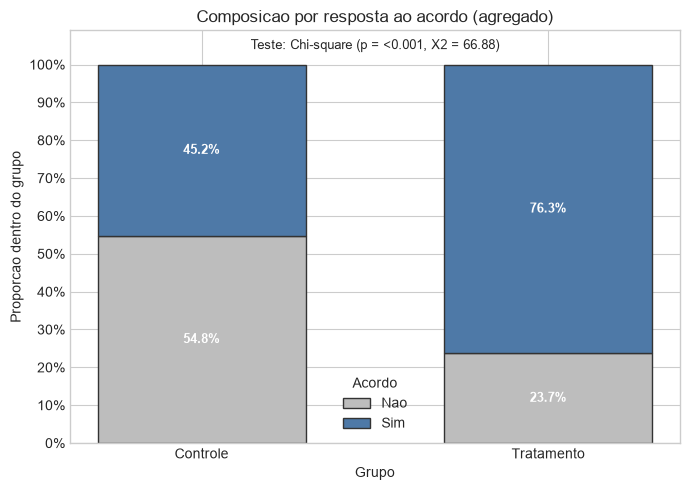

In [16]:
tab_mat = tab.copy()
agg_df = pd.DataFrame(tab_mat, index=["Controle", "Tratamento"], columns=["nao", "sim"]).reset_index(names="grupo")

res = chi_or_fisher_2x2(tab_mat)
if res["test"] == "Fisher":
    pval = res["p"]
    ptxt = "<0.001" if pval < 0.001 else f"{pval:.3g}"
    test_label = f"Fisher exact (p = {ptxt})"
else:
    pval = res["p"]
    ptxt = "<0.001" if pval < 0.001 else f"{pval:.3g}"
    test_label = f"Chi-square (p = {ptxt}, X2 = {res['stat']:.2f})"

plot_df = agg_df.melt(id_vars="grupo", value_vars=["nao", "sim"], var_name="resposta", value_name="contagem")
plot_df["total"] = plot_df.groupby("grupo")["contagem"].transform("sum")
plot_df["prop"] = plot_df["contagem"] / plot_df["total"]
plot_df["pct_label"] = np.where(plot_df["prop"] >= 0.03, (100 * plot_df["prop"]).round(1).astype(str) + "%", "")

grupo_order = ["Controle", "Tratamento"]
x = np.arange(len(grupo_order))
width = 0.6

nao_vals = [plot_df[(plot_df["grupo"] == g) & (plot_df["resposta"] == "nao")]["prop"].iloc[0] for g in grupo_order]
sim_vals = [plot_df[(plot_df["grupo"] == g) & (plot_df["resposta"] == "sim")]["prop"].iloc[0] for g in grupo_order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, nao_vals, width=width, color="#bdbdbd", edgecolor="0.2", label="Nao")
ax.bar(x, sim_vals, width=width, bottom=nao_vals, color="#4E79A7", edgecolor="0.2", label="Sim")

for i, g in enumerate(grupo_order):
    nprop = nao_vals[i]
    sprop = sim_vals[i]
    nlab = plot_df[(plot_df["grupo"] == g) & (plot_df["resposta"] == "nao")]["pct_label"].iloc[0]
    slab = plot_df[(plot_df["grupo"] == g) & (plot_df["resposta"] == "sim")]["pct_label"].iloc[0]
    if nlab:
        ax.text(i, nprop / 2, nlab, ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    if slab:
        ax.text(i, nprop + sprop / 2, slab, ha="center", va="center", color="white", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(grupo_order)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_yticklabels([f"{int(v*100)}%" for v in np.arange(0, 1.01, 0.1)])
ax.set_ylim(0, 1.09)
ax.set_xlabel("Grupo")
ax.set_ylabel("Proporcao dentro do grupo")
ax.set_title("Composicao por resposta ao acordo (agregado)")
ax.text(np.mean(x), 1.05, f"Teste: {test_label}", ha="center", va="center", fontsize=9)
ax.legend(title="Acordo")
plt.tight_layout()
plt.show()

Uma observação importante:  
Muito embora o gráfico acima exiba a importante informação comparativa entre as proporções agragadas observadas nas 4 classes ou categorias da tabela 2x2: Grupos (controle -x- Tratamento) e Acordo (Não -x- Sim).  
__Não__ se pode aplicar a metodologia de cálculo para essas Proporções Observadas.  
Mas __somente para as Frequências Absolutas__, ou seja, as __Contagens__ dos respectivos __'Valores_Observados'__ em cada uma das 4 categorias combinadas.  
__Pois só assim se determina o Valor do Qui-quadrado da amostra com absoluta validade, correção e precisão!__  

### Gráfico barras facetas

O mesmo gráfico acima, um para cada mês, em facetas na ordem cronológica dos meses.

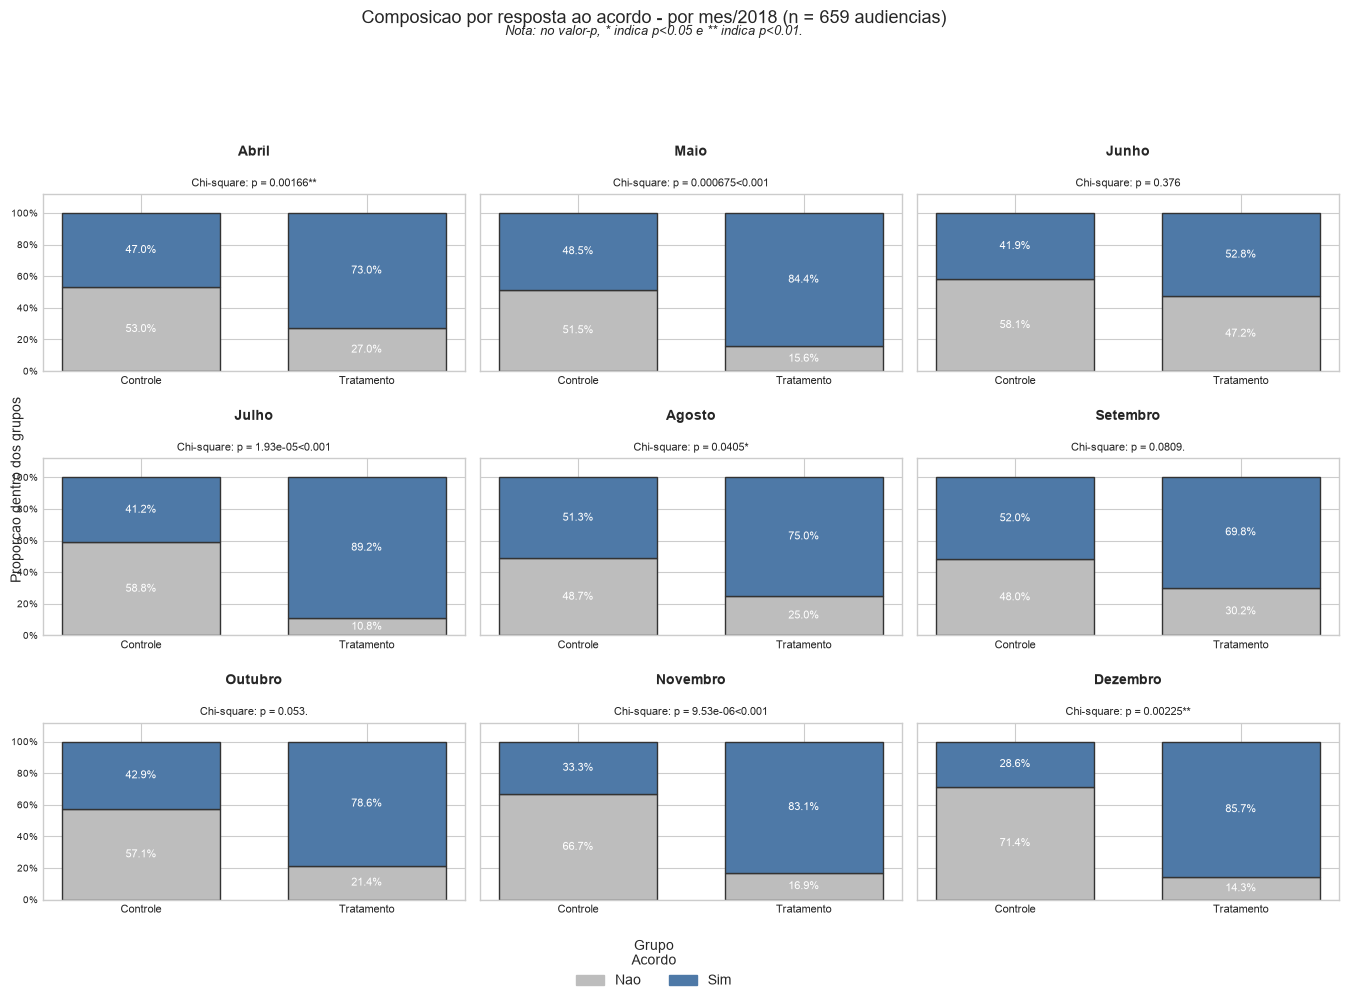

In [25]:
# Gráficos de barras facetas, uma para cada mês

df_raw = tabela_final.copy()
df_raw.columns = [normalize_col(c) for c in df_raw.columns]

df_fac = df_raw.copy()
df_fac["mes_ord"] = pd.Categorical(df_fac["mes"].map(map_month), categories=MONTH_LEVELS, ordered=True)
df_fac["grupo"] = np.where(df_fac["grupo"].str.strip().str.lower().isin(["controle", "control"]), "Controle", "Tratamento")
df_fac["nao"] = pd.to_numeric(df_fac["nao"], errors="coerce")
df_fac["sim"] = pd.to_numeric(df_fac["sim"], errors="coerce")

per_month2 = (
    df_fac.groupby(["mes_ord", "grupo"], as_index=False)[["nao", "sim"]]
    .sum()
)
all_idx2 = pd.MultiIndex.from_product([
    pd.Categorical(MONTH_LEVELS, categories=MONTH_LEVELS, ordered=True),
    ["Controle", "Tratamento"]
], names=["mes_ord", "grupo"])
per_month2 = per_month2.set_index(["mes_ord", "grupo"]).reindex(all_idx2, fill_value=0).reset_index()

p_rows = []
for mes in MONTH_LEVELS:
    sub = per_month2[per_month2["mes_ord"] == mes].set_index("grupo")
    mtx = np.array([
        [sub.loc["Controle", "nao"], sub.loc["Controle", "sim"]],
        [sub.loc["Tratamento", "nao"], sub.loc["Tratamento", "sim"]],
    ], dtype=float)
    out = chi_or_fisher_2x2(mtx)
    p_rows.append({
        "mes_ord": mes,
        "p_value": out["p"],
        "test": out["test"],
        "label": f"{out['test']}: p = {out['p']:.3g}{stars_from_p_facet(out['p'])}",
    })
p_by_month = pd.DataFrame(p_rows)

plot_df = per_month2.melt(id_vars=["mes_ord", "grupo"], value_vars=["nao", "sim"], var_name="resposta", value_name="contagem")
plot_df["total"] = plot_df.groupby(["mes_ord", "grupo"])["contagem"].transform("sum")
plot_df["prop"] = np.where(plot_df["total"] > 0, plot_df["contagem"] / plot_df["total"], 0.0)

# Total de audiencias agregando todos os meses (abril a dezembro/2018).
total_audiencias = int(per_month2[["nao", "sim"]].to_numpy().sum())

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey=True)
axes = axes.ravel()
colors = {"nao": "#bdbdbd", "sim": "#4E79A7"}
for i, mes in enumerate(MONTH_LEVELS):
    ax = axes[i]
    sm = plot_df[plot_df["mes_ord"] == mes]
    grupos = ["Controle", "Tratamento"]
    x = np.arange(len(grupos))
    nao_vals = [sm[(sm["grupo"] == g) & (sm["resposta"] == "nao")]["prop"].iloc[0] for g in grupos]
    sim_vals = [sm[(sm["grupo"] == g) & (sm["resposta"] == "sim")]["prop"].iloc[0] for g in grupos]

    ax.bar(x, nao_vals, color=colors["nao"], width=0.7, edgecolor="0.2")
    ax.bar(x, sim_vals, bottom=nao_vals, color=colors["sim"], width=0.7, edgecolor="0.2")

    for j in range(len(grupos)):
        if nao_vals[j] >= 0.03:
            ax.text(j, nao_vals[j] / 2, f"{100*nao_vals[j]:.1f}%", ha="center", va="center", color="white", fontsize=8)
        if sim_vals[j] >= 0.03:
            ax.text(j, nao_vals[j] + sim_vals[j] / 2, f"{100*sim_vals[j]:.1f}%", ha="center", va="center", color="white", fontsize=8)

    label = p_by_month.loc[p_by_month["mes_ord"] == mes, "label"].iloc[0]
    ax.text(0.5, 1.03, label, transform=ax.transAxes, ha="center", va="bottom", fontsize=8)
    ax.set_title(mes, fontsize=10, fontweight="bold", y=1.17)
    ax.set_xticks(x)
    ax.set_xticklabels(grupos, fontsize=8)
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_yticklabels([f"{int(v*100)}%" for v in np.arange(0, 1.01, 0.2)], fontsize=7)

fig.suptitle(f"Composicao por resposta ao acordo - por mes/2018 (n = {total_audiencias} audiencias)", fontsize=13)
fig.text(
    0.5,
    0.955,
    "\nNota: no valor-p, * indica p<0.05 e ** indica p<0.01.",
    ha="center",
    fontsize=9,
    style="italic",
)
fig.text(0.5, 0.04, "Grupo", ha="center")
fig.text(0.04, 0.5, "Proporcao dentro dos grupos", va="center", rotation="vertical")
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["nao"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["sim"]),
]
fig.legend(legend_handles, ["Nao", "Sim"], title="Acordo", loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0.03, 0.06, 1, 0.90])
plt.show()

Mês de **junho** é explicado pela mudança no nudge para um simples "SIRVA-SE" colocado sobre a mesa em frente às partes (autor e réu).

No mês seguinte, **julho**, retornou-se para o desenho original em que uma pessoa que entrava em cada audiência, servia o suco de uva para as partes e seus advogados e depois dizia: "Podem se servir do suco, pois é uma cortesia do Fórum". Assim como ocorrera nos meses anteriores de **abril e maio**. E assim permaneceu **até o mês de dezembro**.
  
Esse *nudge* mostrou-se muito mais persuasivo.
  
Todavia, registrou-se [**falta de significância**]{.underline}, no nível de confiança adotado de 95% (erro tipo I = 5%), para os meses de [**setembro**]{.underline} e [**outubro**]{.underline}**/2018.**

### Gráfico da Série temporal

Gráfico da Série temporal da proporção de Acordos de Conciliação (Grupos Experimental e de Controle).

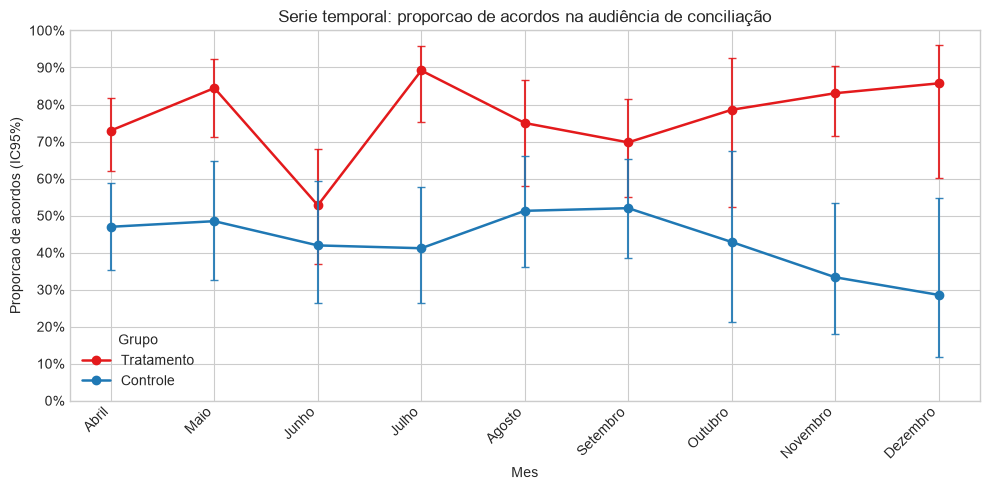

In [27]:
df_ts = tabela_final.copy()
df_ts.columns = [normalize_col(c) for c in df_ts.columns]

df_ts["mes"] = pd.Categorical(df_ts["mes"].map(map_month), categories=MONTH_LEVELS, ordered=True)
df_ts["grupo"] = np.where(df_ts["grupo"].str.strip().str.lower().isin(["controle", "control"]), "Controle", "Tratamento")
df_ts["nao"] = pd.to_numeric(df_ts["nao"], errors="coerce")
df_ts["sim"] = pd.to_numeric(df_ts["sim"], errors="coerce")

per_month_ts = (
    df_ts.groupby(["mes", "grupo"], as_index=False)[["nao", "sim"]]
    .sum()
)
all_idx_ts = pd.MultiIndex.from_product([
    pd.Categorical(MONTH_LEVELS, categories=MONTH_LEVELS, ordered=True),
    ["Controle", "Tratamento"]
], names=["mes", "grupo"])
per_month_ts = per_month_ts.set_index(["mes", "grupo"]).reindex(all_idx_ts, fill_value=0).reset_index()

per_month_ts["total"] = per_month_ts["nao"] + per_month_ts["sim"]
per_month_ts["successes"] = per_month_ts["sim"]
per_month_ts["prop"] = np.where(per_month_ts["total"] > 0, per_month_ts["successes"] / per_month_ts["total"], np.nan)

cis = per_month_ts.apply(lambda r: wilson_ci(int(r["successes"]), int(r["total"])), axis=1)
per_month_ts["ci_low"] = [c[0] for c in cis]
per_month_ts["ci_up"] = [c[1] for c in cis]

plot_df_ts = per_month_ts.copy()
plot_df_ts["grupo"] = pd.Categorical(plot_df_ts["grupo"], categories=["Tratamento", "Controle"], ordered=True)
plot_df_ts = plot_df_ts.sort_values(["grupo", "mes"])

colors = {"Controle": "#1F78B4", "Tratamento": "#E31A1C"}
fig, ax = plt.subplots(figsize=(10, 5))

for g in ["Tratamento", "Controle"]:
    sub = plot_df_ts[plot_df_ts["grupo"] == g]
    x = np.arange(len(sub))
    ax.plot(x, sub["prop"], marker="o", linewidth=1.8, color=colors[g], label=g)
    ax.errorbar(x, sub["prop"], yerr=[sub["prop"] - sub["ci_low"], sub["ci_up"] - sub["prop"]], fmt="none", ecolor=colors[g], capsize=3, alpha=0.9)

ax.set_xticks(np.arange(len(MONTH_LEVELS)))
ax.set_xticklabels(MONTH_LEVELS, rotation=45, ha="right")
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_yticklabels([f"{int(v*100)}%" for v in np.arange(0, 1.01, 0.1)])
ax.set_ylim(0, 1)
ax.set_xlabel("Mes")
ax.set_ylabel("Proporcao de acordos (IC95%)")
ax.set_title("Serie temporal: proporcao de acordos na audiência de conciliação")
ax.legend(title="Grupo")
plt.tight_layout()
plt.show()

A observação de que "2 - Apenas 28 audiências de conciliação aconteceram no mês de [***outubro***]{.underline}. Motivo: férias da magistrada." [@Aline-2020-sucouva , p. 221] não serve de justificativa para a variação observada nesse mês, uma vez que todas as condições do teste foram mantidas e ***não era a magistrada*** que conduzia as audiências de conciliação junto ao CEJUSC.

Outras observações registradas foram:

> "3 A **Semana Nacional de Conciliação** ocorreu entre os dias 5 e 9 de [*novembro*]{.underline} de 2018.
>
> 4 Apenas 28 audiências de conciliação aconteceram no mês de [*dezembro*]{.underline}. Motivo: **Recesso forense** a partir de 20 de dezembro. Fonte: Dados da pesquisa." [@Aline-2020-sucouva , p. 221]

O que também não justifica a variação observada, nos meses de [**setembro**]{.underline} e [**outubro**]{.underline}**/2018**, na replicação mensal deste *quase experimento*.

Como o experimento foi replicado por ***nove meses***, o fato de em dois deles (2 / 9 = 22,2%) ***não resultar estatisticamente significativo*** é uma evidência no sentido de que ele precisa ser novamente replicado, por período igual ou superior; pois há a possibilidade de que o acaso poderia ser uma explicação concorrente para a variabilidade desse subconjunto de insucessos.

E é preciso que suas [**circunstâncias**]{.underline} sejam [**mais detidamente controladas**]{.underline}, tais como:

1. aumentar o período de aplicação para 12 meses;
2. manter um único *nudge* do começo ao fim: pessoa que entra, serve o suco ou a água fresca e sempre repete os mesmos dizeres;
3. essa pessoa que serve não poderá dizer a ninguém o que foi servido em cada audiência;
4. ***aleatorizar*** a ordem de chegada dos casos entre os dois grupos: de controle e tratamento;
5. utilizar *uma mesma sala* de conciliação para os dois grupos, desde que atenda a todas as recomendações da Resolução do CNJ;
6. ***aleatorizar*** qual dos 4 conciliadores (2 homens e 2 mulheres) irá presidir cada audiência de conciliação. Valer-se de pelo menos dois conciliadores treinados e com experiência de pelo menos 3 anos (1 homem e 1 mulher), a serem aleatorizados para cada audiência.
7. ***aleatorizar*** qual técnica de conciliação, entre seis encontradas na revisão da literatura, irá ser aplicada a cada audiência de conciliação;
8. ***organizar as pautas*** das audiências de conciliação de modo a respeitar os itens 4, 5, 6 e 7;
9. para buscar atender um pouco mais ao "*duplo cego*", servir tanto o suco de uva (Grupo de Tratamento) como o placebo água fresca (Grupo de Controle) em *copos de papel descartáveis não transparentes* e *grandes o suficiente*, de modo a evitar que o conciliador possa ver qual tipo de bebida (suco ou água) as partes e seus advogados estão ingerindo;
10. refletir se vale a pena servir água fresca apenas com corante para deixar ela com a mesma cor do suco de uva, mas sem adição de qualquer glicose e dizer que se trata de um "*suco de uva diet*" servido como cortesia na sala do Grupo de Controle;
11. cuidar para que o Grupo de Controle mantenha seu *nível base de acordos observado no início do experimento* (abril a setembro de 2018, cf. *gráfico da série temporal* acima), *evitando-se* assim a *tendência de queda* observada nos meses de setembro a dezembro de 2018;
12. **Evitar** que ***amostras pequenas***, menores que trinta (n < 30), ocorram em qualquer um dos dois Grupos: Controle e Tratamento. Por exemplo, agrupando no mesmo CEJUSC processos oriundos de mais de uma vara nos meses de outubro e dezembro/2018 (n = 14; cf. abaixo gráfico da série temporal da ingestão de suco <sim/não> apenas no Grupo de Tratamento).

### Gráfico da ingestão de suco

Gerar dados sobre ingestão ou não de suco de uva apenas no Grupo de Tratamento.

Tabela como impressa no artigo [@Aline-2020-sucouva , p. 223].  
"Quantidade e proporção de indivíduos que ingeriram e não ingeriram suco no grupo experimental".

![Quantidade e proporção de indivíduos que ingeriram e não ingeriram suco no grupo experimental](fig\dados-suco-uva-tab6-quant-prop-ind-ingeriu-nao_inger-suco_uva.png)

In [31]:
# Replicar a tabela 6 - Quantidade e proporção de indivíduos que ingeriram e
# não ingeriram suco no grupo experimental

from IPython.display import HTML

tabela6_gt = pd.DataFrame(
    {
        "Mes": ["Abril", "Maio", "Junho", "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"],
        "ingeriu_n": [47, 43, 16, 35, 29, 38, 13, 55, 12],
        "nao_ingeriu_n": [27, 2, 20, 2, 3, 5, 1, 4, 2],
    }
)

tabela6_gt["total_n"] = tabela6_gt["ingeriu_n"] + tabela6_gt["nao_ingeriu_n"]
tabela6_gt["prop_ingeriu_pct"] = np.where(
    tabela6_gt["total_n"] > 0,
    100 * tabela6_gt["ingeriu_n"] / tabela6_gt["total_n"],
    np.nan,
 )
tabela6_gt["prop_nao_ingeriu_pct"] = np.where(
    tabela6_gt["total_n"] > 0,
    100 * tabela6_gt["nao_ingeriu_n"] / tabela6_gt["total_n"],
    np.nan,
 )

# Exibe frequência absoluta e, logo abaixo, a proporção entre parênteses.
tabela6_gt["Ingeriu"] = tabela6_gt.apply(
    lambda r: f"{int(r['ingeriu_n'])}<br>({r['prop_ingeriu_pct']:.2f}%)" if pd.notna(r["total_n"]) else np.nan,
    axis=1,
)
tabela6_gt["Nao_ingeriu"] = tabela6_gt.apply(
    lambda r: f"{int(r['nao_ingeriu_n'])}<br>({r['prop_nao_ingeriu_pct']:.2f}%)" if pd.notna(r["total_n"]) else np.nan,
    axis=1,
)
tabela6_gt["Total"] = tabela6_gt.apply(
    lambda r: f"{int(r['total_n'])}<br>(100%)" if pd.notna(r["total_n"]) else np.nan,
    axis=1,
)

tabela_experimental_summary = tabela6_gt[["Mes", "Ingeriu", "Nao_ingeriu", "Total"]].copy()

display(HTML(tabela_experimental_summary.to_html(index=False, escape=False)))

Mes,Ingeriu,Nao_ingeriu,Total
Abril,47(63.51%),27(36.49%),74(100%)
Maio,43(95.56%),2(4.44%),45(100%)
Junho,16(44.44%),20(55.56%),36(100%)
Julho,35(94.59%),2(5.41%),37(100%)
Agosto,29(90.62%),3(9.38%),32(100%)
Setembro,38(88.37%),5(11.63%),43(100%)
Outubro,13(92.86%),1(7.14%),14(100%)
Novembro,55(93.22%),4(6.78%),59(100%)
Dezembro,12(85.71%),2(14.29%),14(100%)


Gráfico da série temporal da ingestão de suco (sim/não) apenas no Grupo de Tratamento.

Com intervalo de confiança 95% para ponto da série.

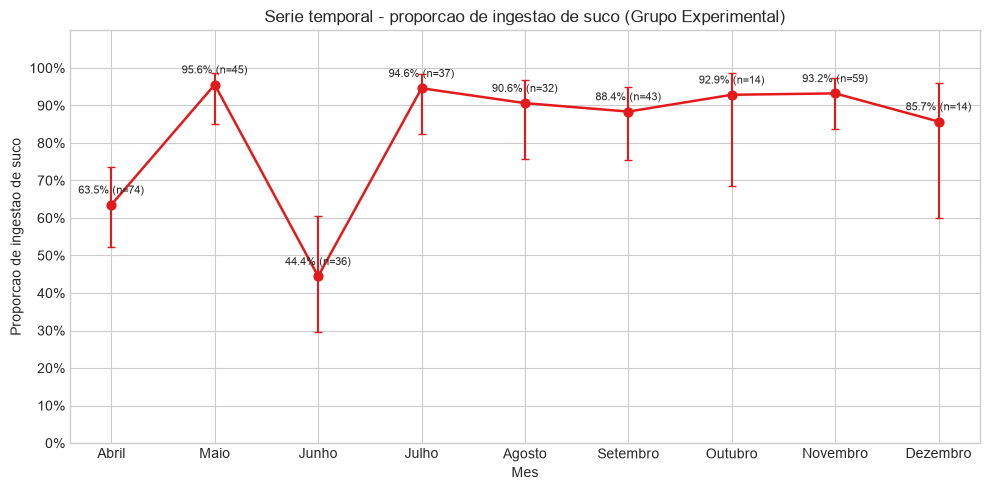

In [32]:
tab_in = tabela_experimental_summary.copy()


def find_col(cols, candidates):
    cols_low = [c.lower() for c in cols]
    cands_low = [c.lower() for c in candidates]
    for c in cands_low:
        if c in cols_low:
            return cols[cols_low.index(c)]
    for pat in cands_low:
        for c in cols:
            if pat in c.lower():
                return c
    return None


def extract_leading_int(values):
    out = []
    for v in values:
        s = re.sub(r"<[^>]+>", "", str(v))
        m = re.search(r"\d+", s)
        out.append(int(m.group()) if m else np.nan)
    return np.array(out, dtype=float)

col_mes = find_col(tab_in.columns.tolist(), ["mes", "month", "m"])
col_ing = find_col(tab_in.columns.tolist(), ["ing_n", "ingere", "ingeriram", "ing"])
col_not = find_col(tab_in.columns.tolist(), ["not_n", "nao_ingere", "nao", "not"])

if col_mes is None:
    raise ValueError("Nao foi possivel localizar coluna de mes em tabela_experimental_summary.")
if col_ing is None or col_not is None:
    raise ValueError("Nao foi possivel localizar colunas de ingestao e nao ingestao.")

ing_vec = extract_leading_int(tab_in[col_ing].values)
not_vec = extract_leading_int(tab_in[col_not].values)

df_ing = pd.DataFrame({"mes_raw": tab_in[col_mes], "ing_n": ing_vec, "not_n": not_vec})
df_ing["mes"] = pd.Categorical(df_ing["mes_raw"].map(map_month), categories=MONTH_LEVELS, ordered=True)
df_ing = df_ing.dropna(subset=["mes"])

per_month_ing = (
    df_ing.groupby("mes", as_index=False)
    .agg(successes=("ing_n", "sum"), total=("ing_n", "sum"))
)
per_month_ing["total"] = (
    df_ing.groupby("mes").apply(lambda x: float(np.nansum(x["ing_n"] + x["not_n"]))).reindex(per_month_ing["mes"]).values
)

full_months = pd.DataFrame({"mes": pd.Categorical(MONTH_LEVELS, categories=MONTH_LEVELS, ordered=True)})
per_month_ing = full_months.merge(per_month_ing, on="mes", how="left").fillna({"successes": 0.0, "total": 0.0})

per_month_ing["prop"] = np.where(per_month_ing["total"] > 0, per_month_ing["successes"] / per_month_ing["total"], np.nan)
ci_vals = per_month_ing.apply(lambda r: wilson_ci(int(r["successes"]), int(r["total"])), axis=1)
per_month_ing["ci_low"] = [c[0] for c in ci_vals]
per_month_ing["ci_up"] = [c[1] for c in ci_vals]

ts_suco_tratamento_table = per_month_ing.copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(per_month_ing))
y = per_month_ing["prop"].values
ax.plot(x, y, color="#E31A1C", linewidth=1.8)
ax.scatter(x, y, color="#E31A1C", s=40)
ax.errorbar(
    x,
    y,
    yerr=[per_month_ing["prop"] - per_month_ing["ci_low"], per_month_ing["ci_up"] - per_month_ing["prop"]],
    fmt="none",
    ecolor="#E31A1C",
    capsize=3,
)

for i, row in per_month_ing.iterrows():
    if pd.notna(row["prop"]):
        ax.text(i, row["prop"] + 0.03, f"{100*row['prop']:.1f}% (n={int(row['total'])})", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(MONTH_LEVELS)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_yticklabels([f"{int(v*100)}%" for v in np.arange(0, 1.01, 0.1)])
ax.set_ylim(0, 1.1)
ax.set_title("Serie temporal - proporcao de ingestao de suco (Grupo Experimental)")
ax.set_xlabel("Mes")
ax.set_ylabel("Proporcao de ingestao de suco")
plt.tight_layout()
plt.show()

O gráfico acima evidencia a falha na troca do *nudge* utilizado apenas no mês de junho/2018.

Ele também evidencia a falta de explicação para a [**ausência de significância estatística**]{.underline} verificada no [**teste qui-quadrado**]{.underline} para os **meses** de [**setembro e outubro/2018**]{.underline}. O que reforça ainda mais a ***necessidade de replicar o quase experimento***, a fim de testar se isso poderia ter sido provocado pela simples álea presente na variabilidade amostral, que se acentua no caso de amostras pequenas, como ocorreu em outubro e dezembro (n = 14), mas não ocorreu em setembro/2018 (n = 43).

### Gráfico do efeito dos conciliadores no GT

Replicar tabela 5 - Desempenho dos conciliadores – Tabelas com qui-quadrado, do artigo [@Aline-2020-sucouva , p. 222].

Tabela 5 – Desempenho dos conciliadores – Tabelas com qui-quadrado (Tomás, 2020, p. 222)  
![](fig\dados-suco-uva-conciliadores-GCxGT-tab5-obs-esp-quiquad.png)  
Qui-quadrado = 33.0268 / P-valor: .00.  
Hipótese nula: não há diferença estatística entre os dois grupos (conciliador e grupos da pesquisa).  
Hipótese alternativa: há diferença estatística entre os dois grupos.  
Ou seja, há uma diferença de desempenho dos conciliadores entre os grupos.  
Fonte: Dados da pesquisa.  
  
Os graus de liberdade da Tabela 5, acima, são:
gl = (l-1).(c-1) = (2-1).(4-1) = 1 . 3 = 3 (três graus de liberdade)  
De modo que o correspondente valor crítico da respectiva distribuição teórica do qui-quadrado é: 7,82

In [33]:
obs_mat_conciliadores = np.array(
    [
        [35, 28, 21, 21],
        [25, 37, 65, 89],
    ],
    dtype=float,
)

row_names = ["Controle", "Experimental"]
col_names = ["Conciliador A", "Conciliador B", "Conciliador C", "Conciliador D"]

row_tot = obs_mat_conciliadores.sum(axis=1)
col_tot = obs_mat_conciliadores.sum(axis=0)
grand_tot = obs_mat_conciliadores.sum()

expected_mat_conciliadores = np.outer(row_tot, col_tot) / grand_tot
chi2_c, p_c, df_c, _ = chi2_contingency(obs_mat_conciliadores, correction=False)

obs_row1 = [str(int(v)) for v in obs_mat_conciliadores[0]]
obs_row2 = [str(int(v)) for v in obs_mat_conciliadores[1]]
exp_row1 = [f"{v:.1f}" for v in expected_mat_conciliadores[0]]
exp_row2 = [f"{v:.1f}" for v in expected_mat_conciliadores[1]]

tabela_conciliadores_display = pd.DataFrame(
    {
        "Grupo": ["Controle", "Esperado", "Experimental", "Esperado", "Total"],
        "Conciliador A": [obs_row1[0], exp_row1[0], obs_row2[0], exp_row2[0], str(int(col_tot[0]))],
        "Conciliador B": [obs_row1[1], exp_row1[1], obs_row2[1], exp_row2[1], str(int(col_tot[1]))],
        "Conciliador C": [obs_row1[2], exp_row1[2], obs_row2[2], exp_row2[2], str(int(col_tot[2]))],
        "Conciliador D": [obs_row1[3], exp_row1[3], obs_row2[3], exp_row2[3], str(int(col_tot[3]))],
        "Total": [
            str(int(row_tot[0])),
            f"{expected_mat_conciliadores[0].sum():.1f}",
            str(int(row_tot[1])),
            f"{expected_mat_conciliadores[1].sum():.1f}",
            str(int(grand_tot)),
        ],
    }
)

display(tabela_conciliadores_display)
print(f"Resultado do qui-quadrado (Pearson): X-squared = {chi2_c:.2f}, df = {int(df_c)}, p-value = {p_c:.6g}")

,Grupo,Conciliador A,Conciliador B,Conciliador C,Conciliador D,Total
0,Controle,35,28,21,21,105
1,Esperado,19.6,21.3,28.1,36.0,105.0
2,Experimental,25,37,65,89,216
3,Esperado,40.4,43.7,57.9,74.0,216.0
4,Total,60,65,86,110,321


Resultado do qui-quadrado (Pearson): X-squared = 33.03, df = 3, p-value = 3.17907e-07


Observar que o total de audiências presididas pelos quatro conciliadores em que foi observado o resultado de cada um deles separadamente foi de **321**.

O que é bem menor que o total geral de audiências do experimento: **659**.

Uma diferença de **-338** audiências, que foi parcialmente explicada no artigo.

> "Durante o primeiro mês da pesquisa (abril de 2018), nenhum registro foi feito em relação aos conciliadores. Apenas a partir de maio de 2018 a variável ‘conciliador’ começou a ser mensurada, não havendo informação sobre a atuação de conciliadores em ***140** audiências realizadas em abril*." [@Aline-2020-sucouva , p. 222]

Gerar gráfico de barras lado a lado para exibir o desempenho dos conciliadores em audiências com acordo no Grupo de Controle e Experimental.

,conciliador,Controle,Experimental,Total
0,A,35,25,60
1,B,28,37,65
2,C,21,65,86
3,D,21,89,110
4,Total,105,216,321


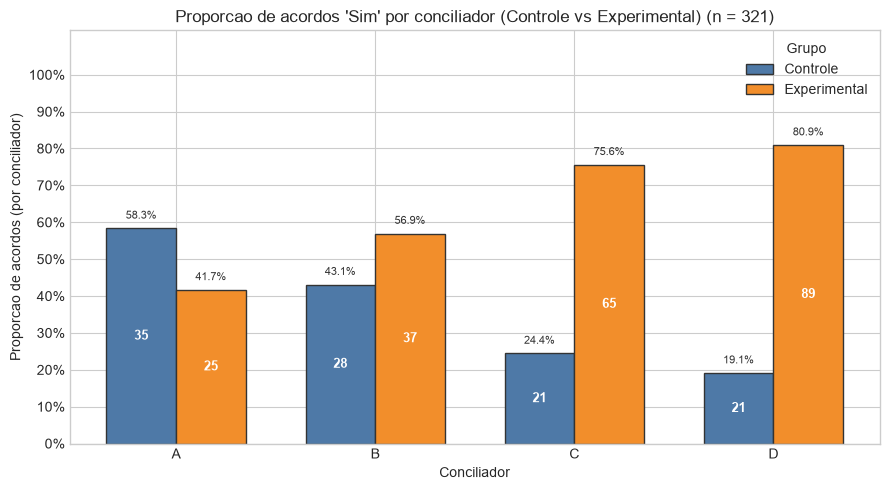

In [43]:
# gráfico de barras lado a lado para exibir o desempenho dos conciliadores
# em audiências com acordo no Grupo de Controle e Experimental.

df_counts_conciliadores = pd.DataFrame(
    {
        "conciliador": ["A", "B", "C", "D"],
        "Controle": obs_mat_conciliadores[0].astype(int),
        "Experimental": obs_mat_conciliadores[1].astype(int),
    }
)

# Tabela com totais marginais (linhas por conciliador e colunas por grupo).
tabela_conciliadores_margens = df_counts_conciliadores.copy()
tabela_conciliadores_margens["Total"] = (
    tabela_conciliadores_margens["Controle"] + tabela_conciliadores_margens["Experimental"]
)

total_controle = int(df_counts_conciliadores["Controle"].sum())
total_experimental = int(df_counts_conciliadores["Experimental"].sum())
total_geral = int(total_controle + total_experimental)

linha_total = pd.DataFrame(
    [{
        "conciliador": "Total",
        "Controle": total_controle,
        "Experimental": total_experimental,
        "Total": total_geral,
    }]
)

tabela_conciliadores_margens = pd.concat(
    [tabela_conciliadores_margens, linha_total],
    ignore_index=True,
)

display(tabela_conciliadores_margens)

plot_long_conciliadores = df_counts_conciliadores.melt(
    id_vars="conciliador", value_vars=["Controle", "Experimental"], var_name="grupo", value_name="agreements"
)
plot_long_conciliadores["total_by_conc"] = plot_long_conciliadores.groupby("conciliador")["agreements"].transform("sum")
plot_long_conciliadores["prop_within_conc"] = np.where(
    plot_long_conciliadores["total_by_conc"] > 0,
    plot_long_conciliadores["agreements"] / plot_long_conciliadores["total_by_conc"],
    0.0,
)

# Total de audiências com acordo consideradas neste gráfico.
total_audiencias_conc = int(df_counts_conciliadores[["Controle", "Experimental"]].to_numpy().sum())

fig, ax = plt.subplots(figsize=(9, 5))
conc = ["A", "B", "C", "D"]
x = np.arange(len(conc))
width = 0.35

vals_ctrl = [
    plot_long_conciliadores[(plot_long_conciliadores["conciliador"] == c) & (plot_long_conciliadores["grupo"] == "Controle")]["prop_within_conc"].iloc[0]
    for c in conc
]
vals_exp = [
    plot_long_conciliadores[(plot_long_conciliadores["conciliador"] == c) & (plot_long_conciliadores["grupo"] == "Experimental")]["prop_within_conc"].iloc[0]
    for c in conc
]

b1 = ax.bar(x - width / 2, vals_ctrl, width, color="#4E79A7", edgecolor="0.2", label="Controle")
b2 = ax.bar(x + width / 2, vals_exp, width, color="#F28E2B", edgecolor="0.2", label="Experimental")

# Exibe a frequência absoluta dentro de cada coluna e a proporção logo acima.
for rect, c in zip(b1, conc):
    h = rect.get_height()
    n_abs = int(df_counts_conciliadores.loc[df_counts_conciliadores["conciliador"] == c, "Controle"].iloc[0])
    ax.text(rect.get_x() + rect.get_width() / 2, h / 2, f"{n_abs}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    ax.text(rect.get_x() + rect.get_width() / 2, h + 0.02, f"{100*h:.1f}%", ha="center", va="bottom", color="0.2", fontsize=8)

for rect, c in zip(b2, conc):
    h = rect.get_height()
    n_abs = int(df_counts_conciliadores.loc[df_counts_conciliadores["conciliador"] == c, "Experimental"].iloc[0])
    ax.text(rect.get_x() + rect.get_width() / 2, h / 2, f"{n_abs}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    ax.text(rect.get_x() + rect.get_width() / 2, h + 0.02, f"{100*h:.1f}%", ha="center", va="bottom", color="0.2", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(conc)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_yticklabels([f"{int(v*100)}%" for v in np.arange(0, 1.01, 0.1)])
ax.set_ylim(0, 1.12)
ax.set_xlabel("Conciliador")
ax.set_ylabel("Proporcao de acordos (por conciliador)")
ax.set_title(f"Proporcao de acordos 'Sim' por conciliador (Controle vs Experimental) (n = {total_audiencias_conc})")
ax.legend(title="Grupo")
plt.tight_layout()
plt.show()

Há um claro padrão discrepante no desempenho dos conciliadores C e D em relação aos conciliadores A e B.

Considerando que todos os conciliadores foram orientados para aplicarem sempre a mesma e única técnica de conciliação, essa discrepância acentuada é uma evidência de que C e D podem ter atuado com mais eficácia no Grupo Experimental que no Grupo de Controle.

In [40]:
# Teste Qui-quadrado de associacao entre conciliador (A, B, C, D) e grupo (Controle/Experimental)

# Objetivo: verificar se ha diferenca estatisticamente significativa no desempenho
# dos conciliadores entre os dois grupos da pesquisa.

# 1) Tabela de frequencias observadas (linhas=grupos, colunas=conciliadores)
obs_mat_conciliadores = np.array(
    [
        [35, 28, 21, 21],  # Controle
        [25, 37, 65, 89],  # Experimental
    ],
    dtype=float,
)

row_names = ["Controle", "Experimental"]
col_names = ["Conciliador A", "Conciliador B", "Conciliador C", "Conciliador D"]

obs_df = pd.DataFrame(obs_mat_conciliadores.astype(int), index=row_names, columns=col_names)
print("Frequencias observadas:")
display(obs_df)

# 2) Executa o teste Qui-quadrado de independencia (sem correcao de Yates)
#    correction=False para manter comparabilidade com o valor reportado no estudo.
chi2_stat, p_value, gl, expected = chi2_contingency(obs_mat_conciliadores, correction=False)

# 3) Tabela de frequencias esperadas sob H0 (independencia)
exp_df = pd.DataFrame(expected, index=row_names, columns=col_names)
print("Frequencias esperadas sob H0:")
display(exp_df.round(4))

# 4) Hipoteses do teste
print("H0: nao ha diferenca estatistica entre os grupos quanto ao desempenho dos conciliadores.")
print("H1: ha diferenca estatistica entre os grupos quanto ao desempenho dos conciliadores.")

# 5) Resultado numerico e decisao
alpha = 0.05
print(f"\nQui-quadrado = {chi2_stat:.4f}")
print(f"gl = {int(gl)}")
print(f"P-valor = {p_value:.6g}")

if p_value < alpha:
    print("Decisao: rejeita-se H0 (p < 0.05).")
    print("Conclusao: há diferenca de desempenho dos conciliadores entre os grupos.")
else:
    print("Decisao: nao se rejeita H0 (p >= 0.05).")
    print("Conclusao: nao ha evidencia suficiente de diferenca de desempenho entre os grupos.")

# 6) Conferencia com o resultado esperado no texto de referencia
print("\nConferencia com o resultado esperado:")
print("Referencia: Qui-quadrado = 33.0268 / P-valor: .00")
print(f"Obtido    : Qui-quadrado = {chi2_stat:.4f} / P-valor = {p_value:.4f}")

Frequencias observadas:


,Conciliador A,Conciliador B,Conciliador C,Conciliador D
Controle,35,28,21,21
Experimental,25,37,65,89


Frequencias esperadas sob H0:


,Conciliador A,Conciliador B,Conciliador C,Conciliador D
Controle,19.6262,21.2617,28.1308,35.9813
Experimental,40.3738,43.7383,57.8692,74.0187


H0: nao ha diferenca estatistica entre os grupos quanto ao desempenho dos conciliadores.
H1: ha diferenca estatistica entre os grupos quanto ao desempenho dos conciliadores.

Qui-quadrado = 33.0268
gl = 3
P-valor = 3.17907e-07
Decisao: rejeita-se H0 (p < 0.05).
Conclusao: há diferenca de desempenho dos conciliadores entre os grupos.

Conferencia com o resultado esperado:
Referencia: Qui-quadrado = 33.0268 / P-valor: .00
Obtido    : Qui-quadrado = 33.0268 / P-valor = 0.0000


Observar que o teste foi realizado apenas nas audiências em que houve acordo.  
O que explica o menor número de observações: n = 321.  
E corrobora a evidência de que pelo menos um dos conciliadores atuou de modo discrepante quando presidia a tentiva de conciliação no Grupo Controle em relação ao Grupo de Tratamento.

Gerar gráfico mosaico com cores para o resíduo padronizado de Pearson para exibir a diferença de desempenho dos conciliadores em audiências com acordo no Grupo de Controle e no Experimental.

e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\.venv\Lib\site-packages\statsmodels\graphics\mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


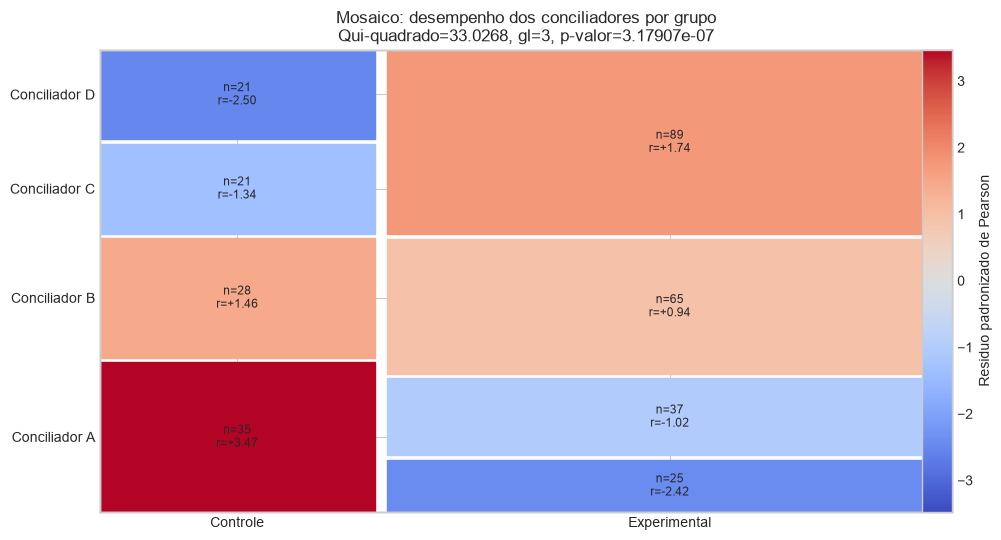

Interpretacao:
- Blocos azuis indicam frequencia observada acima da esperada sob H0.
- Blocos vermelhos indicam frequencia observada abaixo da esperada sob H0.


In [47]:
# Gerar grafico mosaico com cores para o residuo padronizado de Pearson
# para exibir a diferenca de desempenho dos conciliadores em audiencias com acordo
# no Grupo de Controle e no Grupo Experimental.

from statsmodels.graphics.mosaicplot import mosaic
from matplotlib import colors as mcolors
from matplotlib import cm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1) Tabela observada (linhas=grupo; colunas=conciliador)
obs_mat_conciliadores = np.array(
    [
        [35, 28, 21, 21],  # Controle
        [25, 37, 65, 89],  # Experimental
    ],
    dtype=float,
)

grupos = ["Controle", "Experimental"]
conciliadores = ["Conciliador A", "Conciliador B", "Conciliador C", "Conciliador D"]

obs_df = pd.DataFrame(obs_mat_conciliadores.astype(int), index=grupos, columns=conciliadores)

# 2) Teste Qui-quadrado e valores esperados sob H0 de independencia
chi2_stat, p_value, gl, expected = chi2_contingency(obs_mat_conciliadores, correction=False)
exp_df = pd.DataFrame(expected, index=grupos, columns=conciliadores)

# 3) Residuos padronizados de Pearson: (O - E) / sqrt(E)
resid_df = (obs_df - exp_df) / np.sqrt(exp_df)

# 4) Estrutura para o mosaico
counts = obs_df.stack()  # Serie com MultiIndex (grupo, conciliador)
resid_map = {(g, c): float(resid_df.loc[g, c]) for g in grupos for c in conciliadores}
count_map = {(g, c): int(obs_df.loc[g, c]) for g in grupos for c in conciliadores}

# 5) Mapa de cores diverging para os residuos
max_abs = np.abs(resid_df.to_numpy()).max()
if max_abs == 0:
    max_abs = 1.0

norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)
cmap = plt.get_cmap("coolwarm")

def props(key):
    # Azul: acima do esperado; Vermelho: abaixo do esperado
    return {
        "color": cmap(norm(resid_map[key])),
        "edgecolor": "white",
        "linewidth": 1.0,
    }

def labelizer(key):
    # Exibe contagem absoluta e residuo padronizado em cada bloco
    return f"n={count_map[key]}\nr={resid_map[key]:+.2f}"

# 6) Desenha mosaico
fig, ax = plt.subplots(figsize=(11, 6))
mosaic(
    counts,
    ax=ax,
    properties=props,
    labelizer=labelizer,
    gap=0.015,
    axes_label=True,
    title=("Mosaico: desempenho dos conciliadores por grupo\n"
           f"Qui-quadrado={chi2_stat:.4f}, gl={int(gl)}, p-valor={p_value:.6g}"),
)

# 7) Barra de cores em eixo proprio, a direita, sem sobrepor o mosaico
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3.8%", pad=0.25)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Residuo padronizado de Pearson")

plt.show()

print("Interpretacao:")
print("- Blocos azuis indicam frequencia observada acima da esperada sob H0.")
print("- Blocos vermelhos indicam frequencia observada abaixo da esperada sob H0.")

Agora ficou mais clara a distinção de atuação dos conciliadores A e B em relação aos conciliadores C e D.  
Com destaques para os conciliadores:  
A ao autar mais efetivamente para obter Acordo junto ao grupo de Controle.  
D ao autar mais efetivamente para obter Acordo junto ao grupo Experimental.  